# Dataset 1 — Credit Card Customers (Customer Churn)
**Final Classical ML Project (Portfolio Level)**

**Objective:** to'liq Machine Learning pipeline — EDA, Data Cleaning, Feature Engineering, Feature Importance, Model Training, Hyperparameter Tuning, Model Comparison.

- **Target:** `Attrition_Flag` (Attrited Customer = 1, Existing Customer = 0)
- **Dropped columns:** `CLIENTNUM` (unique ID), 2 ta `Naive_Bayes_Classifier_...` ustunlari (Kaggle'dagi tasodifiy/leakage ustunlar, rasmiy dataset tavsifida o'chirish tavsiya etiladi)
- **Source:** Kaggle — Credit Card Customers Dataset (`sakshigoyal7/credit-card-customers`)


In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

## Part 1 — Exploratory Data Analysis (EDA)

### 1. Dataset haqida umumiy ma'lumot

In [2]:
df_raw = pd.read_csv("data/BankChurners.csv")
nb_cols = [c for c in df_raw.columns if c.startswith("Naive_Bayes_Classifier")]
df = df_raw.drop(columns=["CLIENTNUM"] + nb_cols)

print("Shape:", df.shape)
print("Ustunlar soni:", df.shape[1], "| Observationlar soni:", df.shape[0])
df.info()
print("\nMemory usage:", round(df.memory_usage(deep=True).sum()/1024, 2), "KB")

Shape: (10127, 20)
Ustunlar soni: 20 | Observationlar soni: 10127
<class 'pandas.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Attrition_Flag            10127 non-null  str    
 1   Customer_Age              10127 non-null  int64  
 2   Gender                    10127 non-null  str    
 3   Dependent_count           10127 non-null  int64  
 4   Education_Level           10127 non-null  str    
 5   Marital_Status            10127 non-null  str    
 6   Income_Category           10127 non-null  str    
 7   Card_Category             10127 non-null  str    
 8   Months_on_book            10127 non-null  int64  
 9   Total_Relationship_Count  10127 non-null  int64  
 10  Months_Inactive_12_mon    10127 non-null  int64  
 11  Contacts_Count_12_mon     10127 non-null  int64  
 12  Credit_Limit              10127 non-null  float64
 13  Total_

**Xulosa:** Dataset 10,127 ta mijoz va (CLIENTNUM hamda 2 ta Naive-Bayes yordamchi ustunni olib tashlagandan so'ng) 20 ta ustundan iborat. Xotira hajmi ~2069 KB. 9 ta int64, 5 ta float64, 6 ta object (categorical) ustun mavjud.

### 2. Missing Values Analysis

In [3]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({"missing": missing, "pct": missing_pct})[missing > 0])
print("Jami missing qiymatlar:", missing.sum())

# "Unknown" placeholder kategoriyalar (NaN emas, lekin amalda noma'lum qiymat)
for col in df.select_dtypes(include="object").columns:
    n = (df[col] == "Unknown").sum()
    if n > 0:
        print(f"{col}: {n} ta 'Unknown' qiymat ({n/len(df)*100:.2f}%)")

Empty DataFrame
Columns: [missing, pct]
Index: []
Jami missing qiymatlar: 0
Education_Level: 1519 ta 'Unknown' qiymat (15.00%)
Marital_Status: 749 ta 'Unknown' qiymat (7.40%)
Income_Category: 1112 ta 'Unknown' qiymat (10.98%)


**Xulosa:** Klassik ma'noda (NaN) missing value yo'q — 0 ta. Ammo `Education_Level` (1519), `Marital_Status` (749) va `Income_Category` (1112) ustunlarida "Unknown" degan maxsus kategoriya mavjud bo'lib, bu amalda ma'lumot yetishmasligini bildiradi. Bu qiymatlarni alohida kategoriya sifatida qoldirish qaror qilindi (o'chirish katta ma'lumot yo'qotilishiga olib keladi), chunki daraxt-asosli modellar (XGBoost/LightGBM/CatBoost) bunday kategoriyalarni yaxshi boshqaradi.

### 3. Duplicate Analysis

In [4]:
dup_count = df.duplicated().sum()
print("Duplicate qatorlar soni:", dup_count)
df = df.drop_duplicates()
print("Tozalashdan keyingi shape:", df.shape)

Duplicate qatorlar soni: 0
Tozalashdan keyingi shape: (10127, 20)


**Xulosa:** Duplicate qatorlar topilmadi (0 ta), shuning uchun qo'shimcha tozalash talab qilinmadi.

### 4. Target Variable Analysis

Attrition_Flag
Existing Customer    8500
Attrited Customer    1627
Name: count, dtype: int64
Attrition_Flag
Existing Customer    83.93
Attrited Customer    16.07
Name: count, dtype: float64


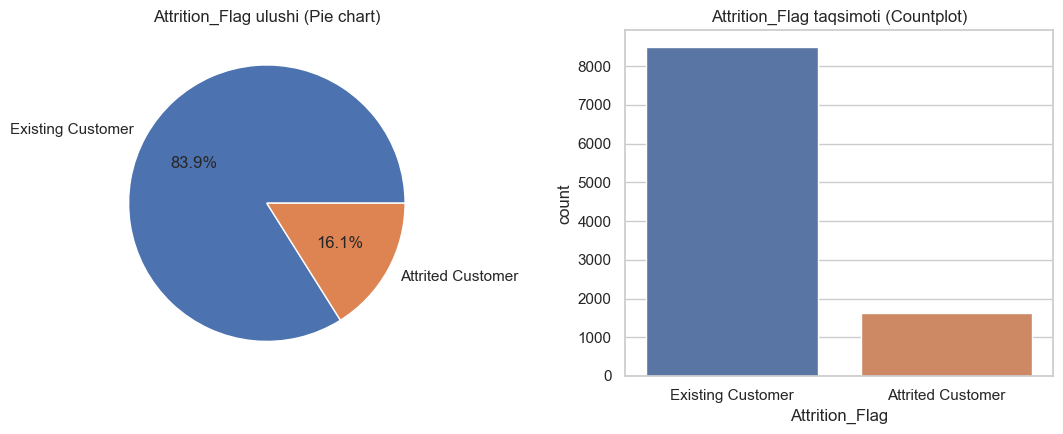

In [5]:
target = "Attrition_Flag"
target_counts = df[target].value_counts()
target_pct = (target_counts / len(df) * 100).round(2)
print(target_counts)
print(target_pct)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
target_counts.plot.pie(autopct="%1.1f%%", ax=axes[0], colors=["#4C72B0", "#DD8452"], ylabel="")
axes[0].set_title("Attrition_Flag ulushi (Pie chart)")
sns.countplot(x=target, data=df, ax=axes[1], hue=target, legend=False, palette=["#4C72B0", "#DD8452"])
axes[1].set_title("Attrition_Flag taqsimoti (Countplot)")
plt.tight_layout()
plt.savefig("images/01_target_distribution.png", dpi=110)
plt.show()

**Xulosa:** Target **Imbalanced** (nomutanosib): Existing Customer 83.93% (8500 ta), Attrited Customer 16.07% (1627 ta). Bu ~5.2:1 nisbat classification metrikalarini tanlashga ta'sir qiladi — faqat Accuracy yetarli emas, Precision/Recall/F1/ROC-AUC (ayniqsa churn klassi bo'yicha) muhimroq.

### 5. Numerical Features Analysis

In [6]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = [c for c in df.select_dtypes(include="object").columns if c != target]
print("Numerical:", num_cols)
print("Categorical:", cat_cols)

desc = df[num_cols].describe().T[["mean", "50%", "std", "min", "max", "25%", "75%"]]
desc.columns = ["mean", "median", "std", "min", "max", "q25", "q75"]
desc.round(2)

Numerical: ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']
Categorical: ['Gender', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category']


,mean,median,std,min,max,q25,q75
Customer_Age,46.33,46.00,8.02,26.0,73.00,41.00,52.00
Dependent_count,2.35,2.00,1.30,0.0,5.00,1.00,3.00
Months_on_book,35.93,36.00,7.99,13.0,56.00,31.00,40.00
Total_Relationship_Count,3.81,4.00,1.55,1.0,6.00,3.00,5.00
Months_Inactive_12_mon,2.34,2.00,1.01,0.0,6.00,2.00,3.00
Contacts_Count_12_mon,2.46,2.00,1.11,0.0,6.00,2.00,3.00
Credit_Limit,8631.95,4549.00,9088.78,1438.3,34516.00,2555.00,11067.50
Total_Revolving_Bal,1162.81,1276.00,814.99,0.0,2517.00,359.00,1784.00
Avg_Open_To_Buy,7469.14,3474.00,9090.69,3.0,34516.00,1324.50,9859.00
Total_Amt_Chng_Q4_Q1,0.76,0.74,0.22,0.0,3.40,0.63,0.86


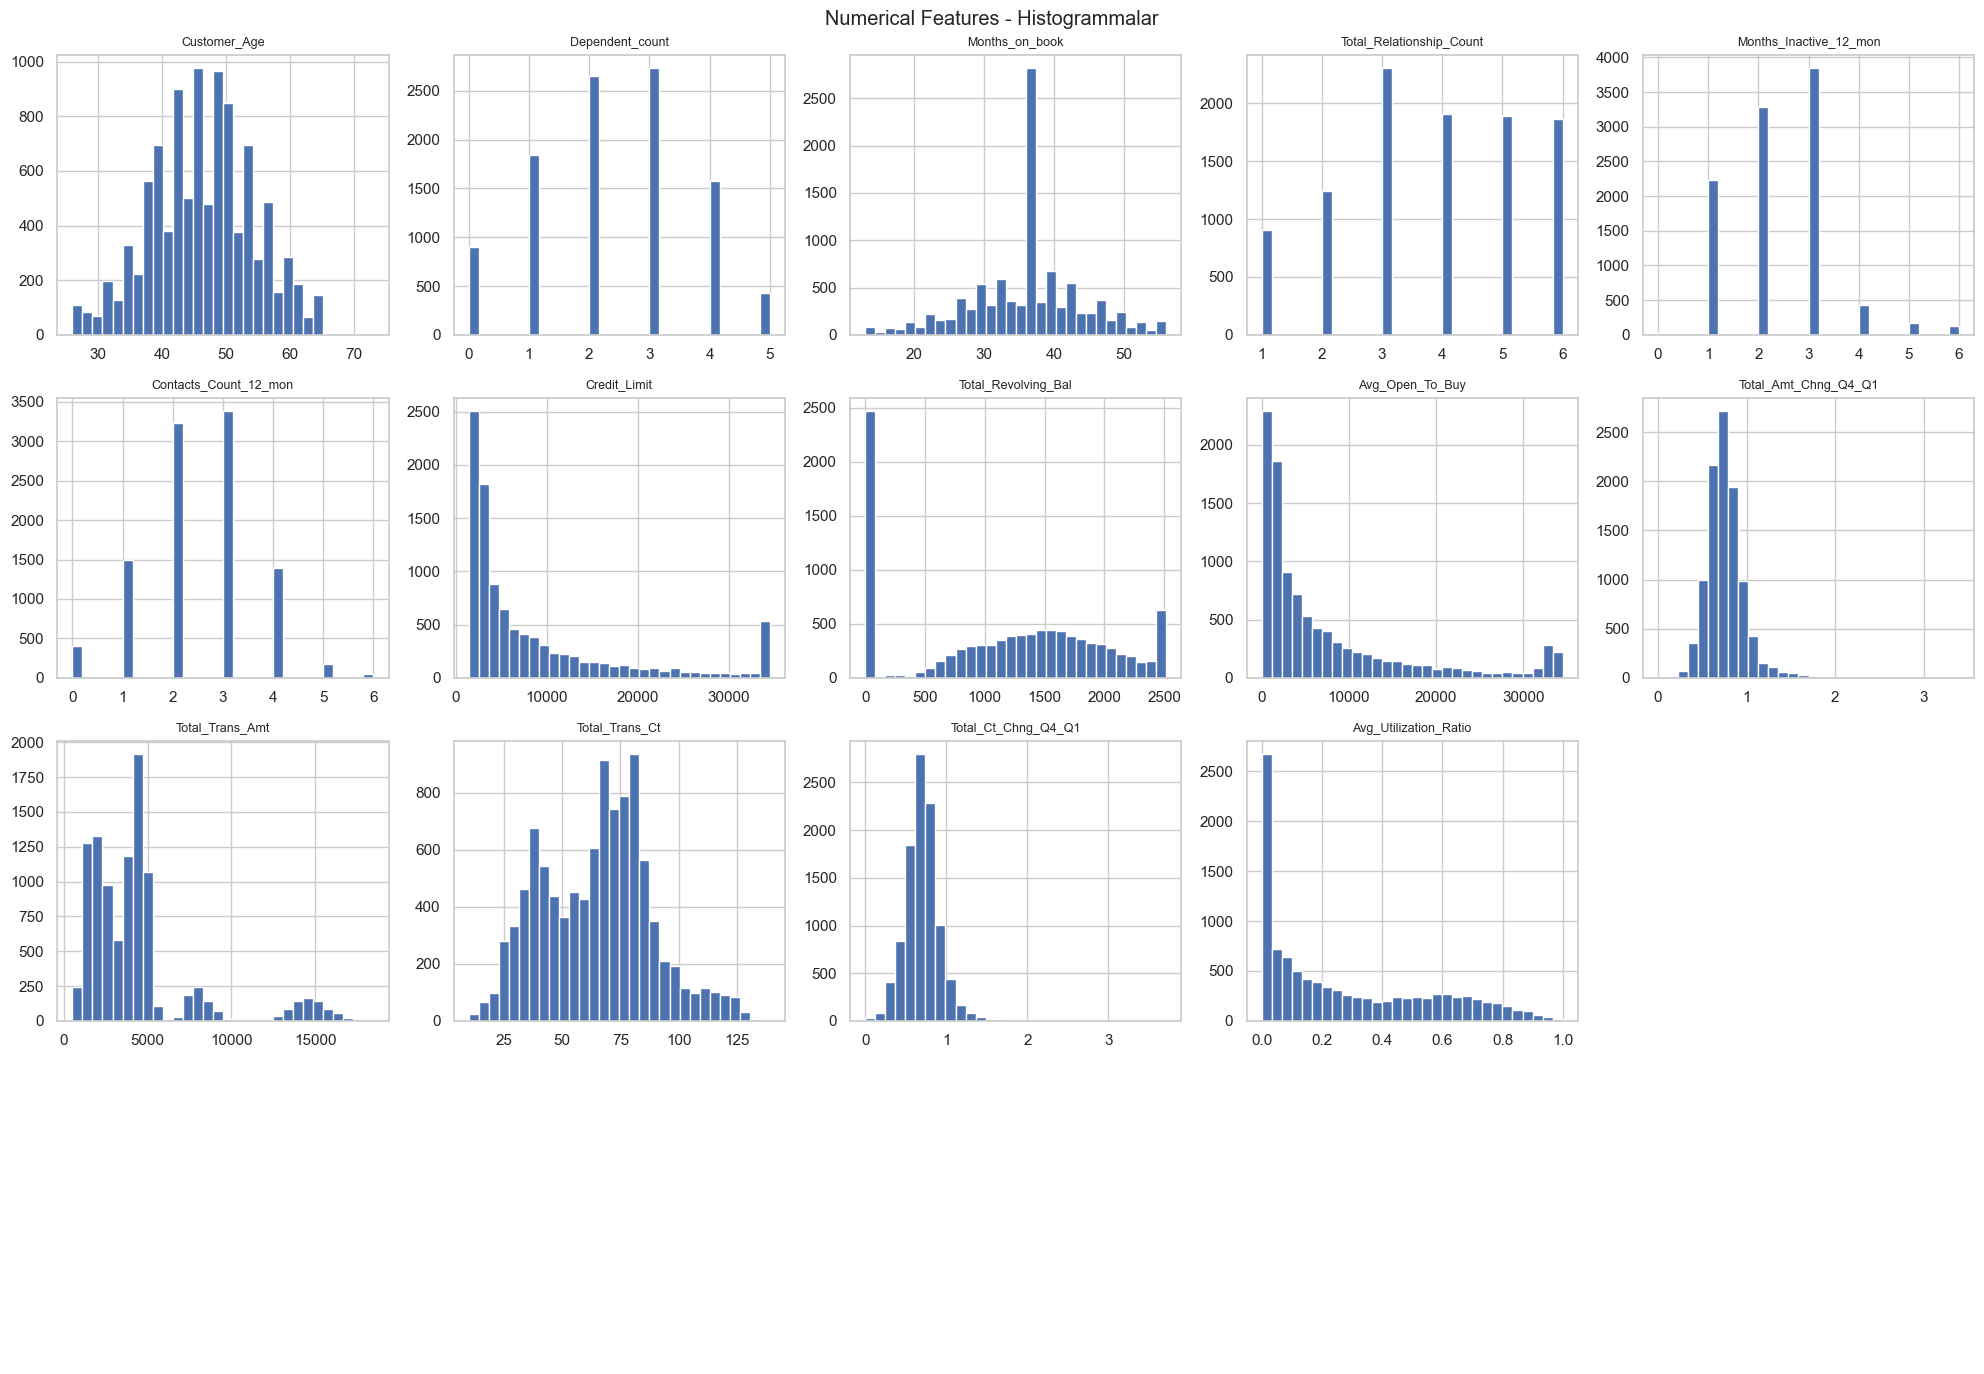

In [7]:
fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color="#4C72B0", edgecolor="white")
    axes[i].set_title(col, fontsize=9)
for j in range(i+1, len(axes)):
    axes[j].axis("off")
plt.suptitle("Numerical Features - Histogrammalar")
plt.tight_layout()
plt.savefig("images/02_histograms.png", dpi=110)
plt.show()

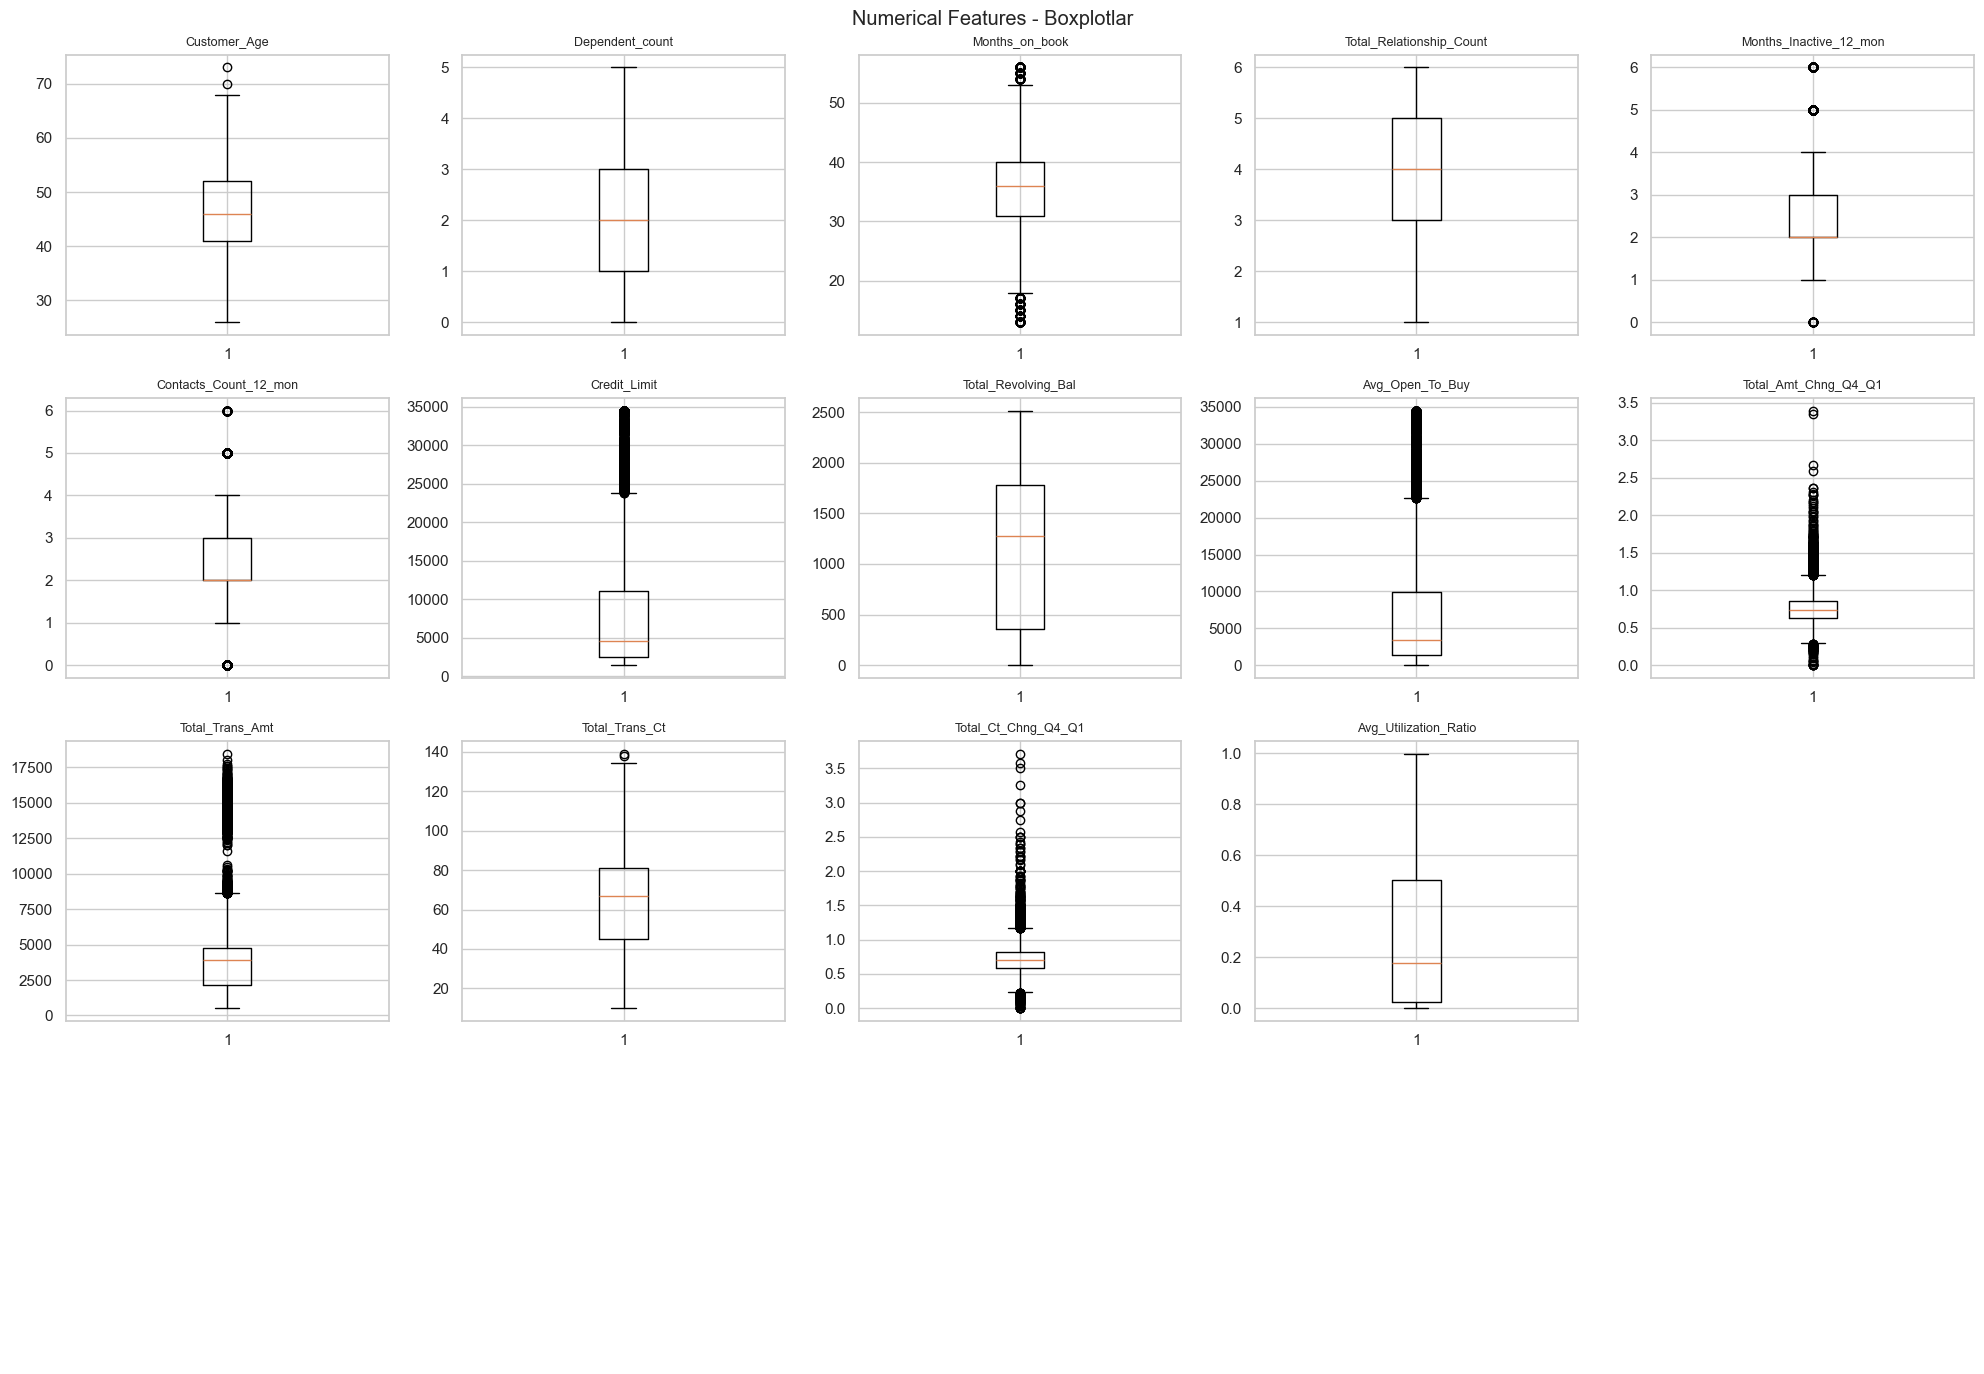

In [8]:
fig, axes = plt.subplots(4, 5, figsize=(20, 14))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col], vert=True)
    axes[i].set_title(col, fontsize=9)
for j in range(i+1, len(axes)):
    axes[j].axis("off")
plt.suptitle("Numerical Features - Boxplotlar")
plt.tight_layout()
plt.savefig("images/03_boxplots.png", dpi=110)
plt.show()

**Xulosa:** `Customer_Age` o'rtacha 46.3 yosh (26-73 oralig'ida). `Credit_Limit` juda keng tarqalgan (mean 8632 vs median 4549 — o'ng tomonga cho'zilgan taqsimot). `Total_Trans_Amt` va `Total_Trans_Ct` ham o'ng tomonga qiyshiq (skewed) taqsimotga ega.

### 6. Outlier Analysis

In [9]:
outlier_info = {}
for col in num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_info[col] = {"count": int(n_out), "pct": round(n_out/len(df)*100, 2)}

outlier_df = pd.DataFrame(outlier_info).T.sort_values("count", ascending=False)
outlier_df

,count,pct
Credit_Limit,984.0,9.72
Avg_Open_To_Buy,963.0,9.51
Total_Trans_Amt,896.0,8.85
Contacts_Count_12_mon,629.0,6.21
Total_Amt_Chng_Q4_Q1,396.0,3.91
Total_Ct_Chng_Q4_Q1,394.0,3.89
Months_on_book,386.0,3.81
Months_Inactive_12_mon,331.0,3.27
Customer_Age,2.0,0.02
Total_Trans_Ct,2.0,0.02


**Xulosa:** Eng ko'p outlier (IQR usuli bo'yicha) `Credit_Limit` (9.72%) va `Avg_Open_To_Buy` (9.51%) ustunlarida, chunki bu moliyaviy ustunlar tabiatan keng diapazonga ega (Blue/Silver/Gold/Platinum kartalar juda farqli limitlarga ega). **Qaror:** outlierlar olib tashlanmaydi — ular haqiqiy, business jihatdan mazmunli qiymatlar (yuqori limitli VIP mijozlar), va gradient boosting modellar outlierlarga chidamli (robust).

### 7. Categorical Features Analysis

--- Gender (unique=2) ---
Gender
F    5358
M    4769
Name: count, dtype: int64 

--- Education_Level (unique=7) ---
Education_Level
Graduate         3128
High School      2013
Unknown          1519
Uneducated       1487
College          1013
Post-Graduate     516
Doctorate         451
Name: count, dtype: int64 

--- Marital_Status (unique=4) ---
Marital_Status
Married     4687
Single      3943
Unknown      749
Divorced     748
Name: count, dtype: int64 

--- Income_Category (unique=6) ---
Income_Category
Less than $40K    3561
$40K - $60K       1790
$80K - $120K      1535
$60K - $80K       1402
Unknown           1112
$120K +            727
Name: count, dtype: int64 



--- Card_Category (unique=4) ---
Card_Category
Blue        9436
Silver       555
Gold         116
Platinum      20
Name: count, dtype: int64 



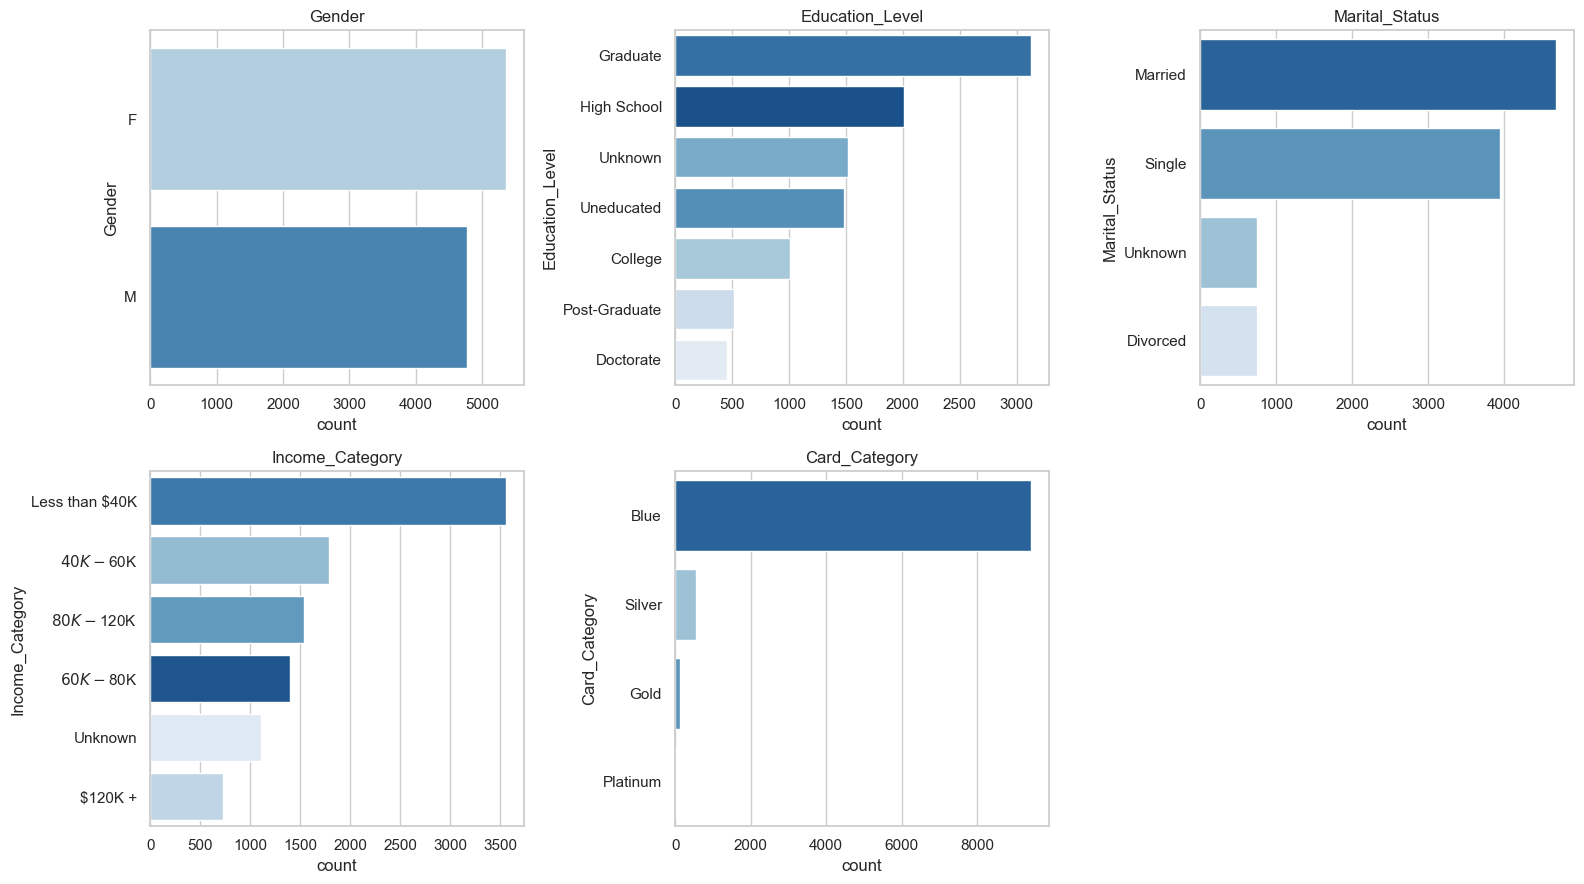

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    vc = df[col].value_counts()
    print(f"--- {col} (unique={df[col].nunique()}) ---")
    print(vc, "\n")
    sns.countplot(y=col, data=df, order=vc.index, ax=axes[i], hue=col, legend=False, palette="Blues_r")
    axes[i].set_title(col)
for j in range(i+1, len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("images/04_categorical_bars.png", dpi=110)
plt.show()

**Savol — eng ko'p uchraydigan kategoriya:** Gender: F (5358); Education_Level: Graduate (3128); Marital_Status: Married (4687); Income_Category: Less than $40K (3561); Card_Category: Blue (9436, ya'ni 93%+ mijozlar oddiy Blue kartadan foydalanadi).

### 8. Correlation Analysis

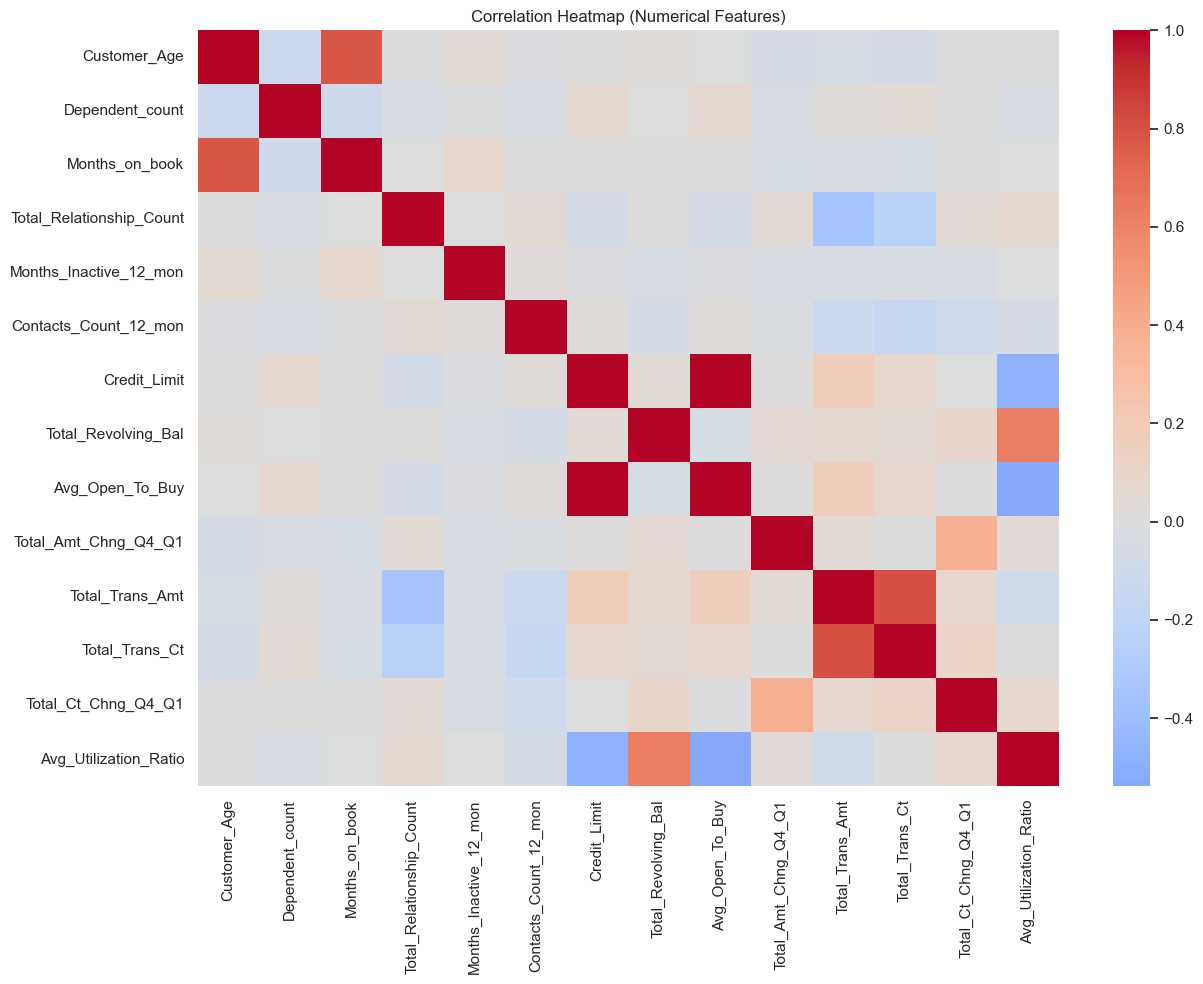

Eng kuchli musbat:
 Avg_Open_To_Buy  Credit_Limit       0.995981
Credit_Limit     Avg_Open_To_Buy    0.995981
Total_Trans_Amt  Total_Trans_Ct     0.807192
dtype: float64

Eng kuchli manfiy:
 Avg_Open_To_Buy        Avg_Utilization_Ratio   -0.538808
Avg_Utilization_Ratio  Avg_Open_To_Buy         -0.538808
                       Credit_Limit            -0.482965
dtype: float64

Deyarli bog'liq emas:
 Customer_Age     Avg_Open_To_Buy        0.001151
Avg_Open_To_Buy  Customer_Age           0.001151
Credit_Limit     Total_Ct_Chng_Q4_Q1    0.002020
dtype: float64


In [11]:
corr = df[num_cols].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.savefig("images/05_correlation_heatmap.png", dpi=110)
plt.show()

corr_pairs = corr.where(~np.eye(len(corr), dtype=bool)).unstack().dropna()
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]
print("Eng kuchli musbat:\n", corr_pairs.sort_values(ascending=False).head(3))
print("\nEng kuchli manfiy:\n", corr_pairs.sort_values().head(3))
print("\nDeyarli bog'liq emas:\n", corr_pairs.abs().sort_values().head(3))

**Savollar:**
- **Eng kuchli musbat bog'liqlik:** `Avg_Open_To_Buy` va `Credit_Limit` (r=0.996) — mantiqan to'g'ri, chunki Open-to-Buy = Credit Limit - Revolving Balance.
- **Eng kuchli manfiy bog'liqlik:** `Avg_Open_To_Buy` va `Avg_Utilization_Ratio` (r=-0.539) — limit ko'p ishlatilmagan mijozlarda ochiq limit yuqori bo'ladi, bu tabiiy.
- **Deyarli bog'liq emas:** `Customer_Age` va `Avg_Open_To_Buy` (r≈0.001) — yosh kredit limitiga deyarli ta'sir qilmaydi.

### 9. Relationship Analysis

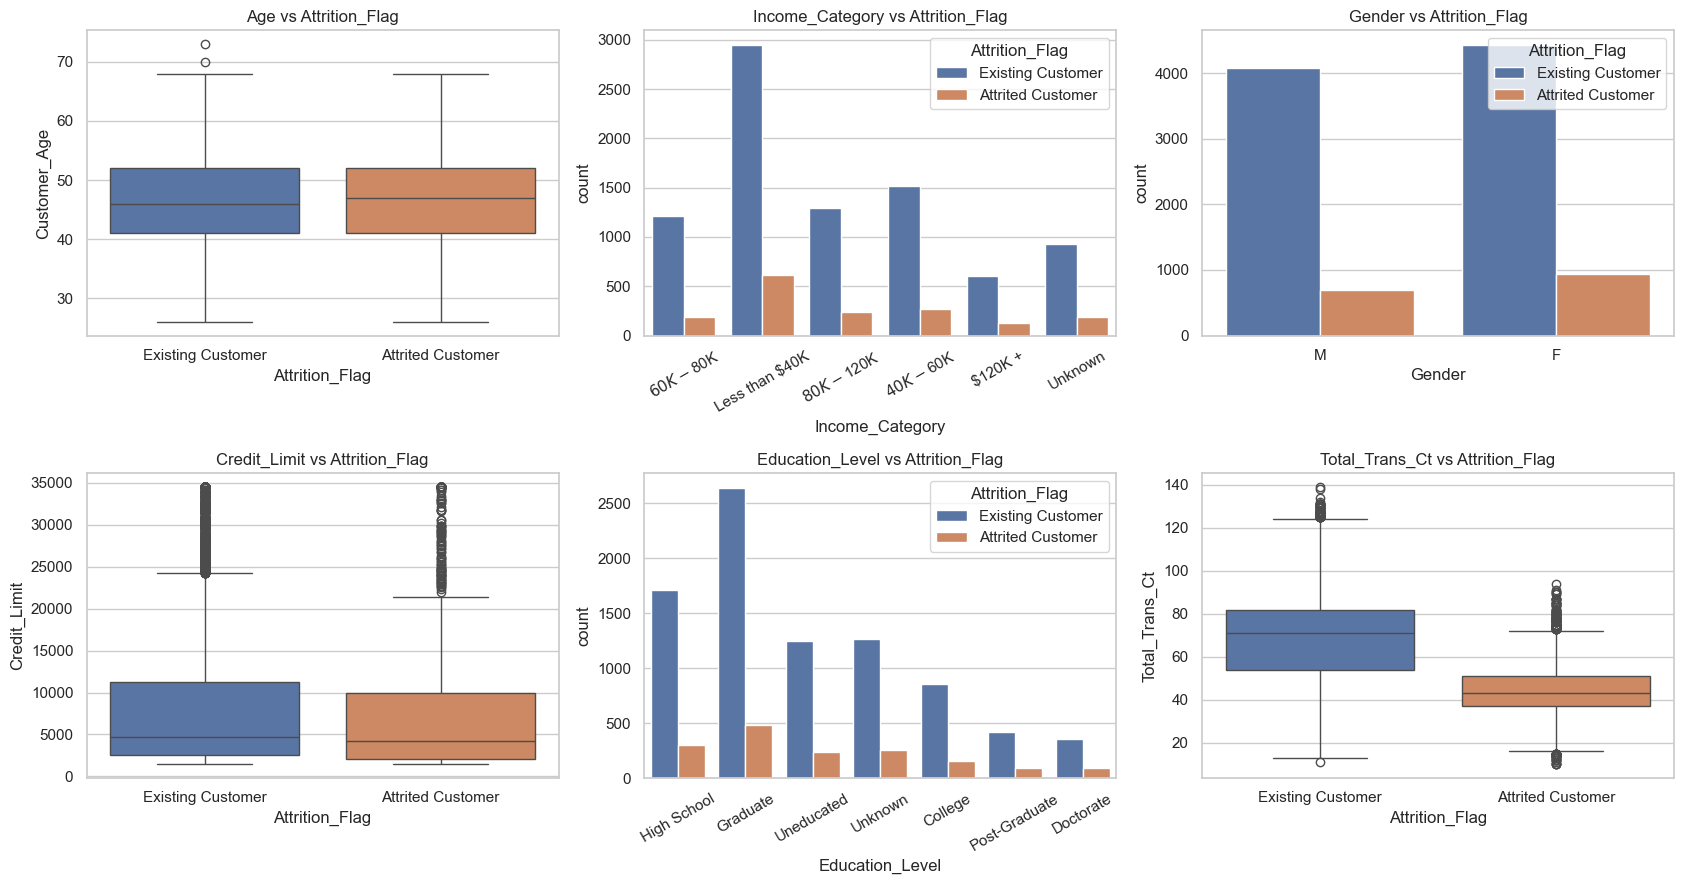

Attrition_Flag
Attrited Customer    46.7
Existing Customer    46.3
Name: Customer_Age, dtype: float64
Attrition_Flag
Attrited Customer    8136.0
Existing Customer    8726.9
Name: Credit_Limit, dtype: float64
Attrition_Flag
Attrited Customer    44.9
Existing Customer    68.7
Name: Total_Trans_Ct, dtype: float64


In [12]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
sns.boxplot(x=target, y="Customer_Age", data=df, ax=axes[0,0], hue=target, legend=False)
axes[0,0].set_title("Age vs Attrition_Flag")
sns.countplot(x="Income_Category", hue=target, data=df, ax=axes[0,1])
axes[0,1].set_title("Income_Category vs Attrition_Flag"); axes[0,1].tick_params(axis="x", rotation=30)
sns.countplot(x="Gender", hue=target, data=df, ax=axes[0,2])
axes[0,2].set_title("Gender vs Attrition_Flag")
sns.boxplot(x=target, y="Credit_Limit", data=df, ax=axes[1,0], hue=target, legend=False)
axes[1,0].set_title("Credit_Limit vs Attrition_Flag")
sns.countplot(x="Education_Level", hue=target, data=df, ax=axes[1,1])
axes[1,1].set_title("Education_Level vs Attrition_Flag"); axes[1,1].tick_params(axis="x", rotation=30)
sns.boxplot(x=target, y="Total_Trans_Ct", data=df, ax=axes[1,2], hue=target, legend=False)
axes[1,2].set_title("Total_Trans_Ct vs Attrition_Flag")
plt.tight_layout()
plt.savefig("images/06_relationships.png", dpi=110)
plt.show()

print(df.groupby(target)["Customer_Age"].mean().round(1))
print(df.groupby(target)["Credit_Limit"].mean().round(1))
print(df.groupby(target)["Total_Trans_Ct"].mean().round(1))

**Xulosalar (har bir grafik ostida):**
1. **Age vs Target:** yosh deyarli bir xil (Attrited 46.7 vs Existing 46.3) — yosh kuchli signal emas.
2. **Income_Category vs Target:** barcha daromad guruhlarida churn nisbati taxminan bir xil — daromad yolg'iz predictor emas.
3. **Gender vs Target:** attrited mijozlarning 57.2% ayollar, 42.8% erkaklar — ayollarda biroz yuqoriroq churn.
4. **Credit_Limit vs Target:** Attrited mijozlarda o'rtacha limit past (8136 vs 8727) — churn qilganlar biroz kamroq limitga ega.
5. **Total_Trans_Ct vs Target:** eng katta farq shu yerda — Attrited mijozlar o'rtacha 44.9 ta tranzaksiya, Existing esa 68.7 ta. Bu **eng kuchli signal** — faollik pasayishi churn bilan bevosita bog'liq.

### 10. EDA Summary

**Eng muhim 5 ta kuzatuv:**
1. Target juda **imbalanced** (83.9% / 16.1%) — modellashda class imbalance'ga e'tibor kerak (masalan, F1/ROC-AUC, class_weight).
2. `Total_Trans_Ct` va `Total_Trans_Amt` churn bilan eng kuchli bog'langan behavioral signal — faollik pasayishi asosiy churn belgisi.
3. `Credit_Limit` va `Avg_Open_To_Buy` deyarli bir xil ma'lumotni tashiydi (r=0.996) — multicollinearity, lekin tree-based modellar uchun muammo emas.
4. `Education_Level`, `Marital_Status`, `Income_Category`da "Unknown" kategoriya sezilarli ulushni tashkil qiladi (7-15%) — alohida kategoriya sifatida saqlanadi.
5. Demografik xususiyatlar (Age, Gender, Education) kuchsiz signal, **behavioral/transactional** xususiyatlar (Trans_Ct, Trans_Amt, Revolving_Bal) kuchli signal beradi.

**Model qurishdan oldin e'tibor berish kerak bo'lgan narsalar:** class imbalance, categorical encoding (Unknown dahil), va Credit_Limit/Avg_Open_To_Buy kabi yuqori korrelyatsiyali juftliklarga (feature selection bosqichida hisobga olinadi).

## Part 2 — Data Preprocessing

**Bajarilgan qadamlar va izohlar:**
- **Missing values:** haqiqiy NaN yo'q, shuning uchun imputatsiya talab qilinmadi. "Unknown" kategoriyalari o'z holida qoldirildi.
- **Duplicate removal:** 0 ta duplicate topildi, olib tashlashning hojati bo'lmadi.
- **Encoding:** target `Attrition_Flag` explicit mapping bilan encode qilindi — **Attrited Customer = 1** (churn/musbat klass), **Existing Customer = 0**, chunki business maqsad — kim churn qilishini bashorat qilish (agar LabelEncoder alifbo tartibida ishlatilsa, noto'g'ri klass "musbat" bo'lib qolar edi). Categorical ustunlar (Gender, Education_Level, Marital_Status, Income_Category, Card_Category) One-Hot Encoding orqali kodlandi.
- **Scaling:** amalga oshirilmadi — barcha 3 model (XGBoost, LightGBM, CatBoost) daraxt-asosli (tree-based) bo'lib, feature scale'ga sezgir emas (faqat split-point tanlaydi, masofaga asoslanmaydi).
- **Feature Engineering (2 ta yangi feature):**
  - `Trans_Amt_per_Trans` = Total_Trans_Amt / Total_Trans_Ct — bitta tranzaksiyaning o'rtacha summasi.
  - `Inactivity_Ratio` = Months_Inactive_12_mon / Months_on_book — umumiy mijozlik davomiga nisbatan faolsizlik darajasi.


In [13]:
df_model = df.copy()
target_mapping = {"Existing Customer": 0, "Attrited Customer": 1}
df_model[target] = df_model[target].map(target_mapping)

df_model["Trans_Amt_per_Trans"] = (df_model["Total_Trans_Amt"] / df_model["Total_Trans_Ct"].replace(0, np.nan)).fillna(0)
df_model["Inactivity_Ratio"] = (df_model["Months_Inactive_12_mon"] / df_model["Months_on_book"].replace(0, np.nan)).fillna(0)

cat_cols_enc = df_model.select_dtypes(include="object").columns.tolist()
df_model = pd.get_dummies(df_model, columns=cat_cols_enc, drop_first=True)
print("Encoding'dan keyingi feature soni:", df_model.shape[1] - 1)

X = df_model.drop(columns=[target])
y = df_model[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print("Train shape:", X_train.shape, "| Test shape:", X_test.shape)

Encoding'dan keyingi feature soni: 34
Train shape: (8101, 34) | Test shape: (2026, 34)


## Part 3 — Feature Importance

Model sifatida Random Forest ishlatildi (300 ta daraxt).

Total_Trans_Ct              0.153738
Total_Trans_Amt             0.152100
Total_Revolving_Bal         0.100181
Total_Ct_Chng_Q4_Q1         0.099643
Trans_Amt_per_Trans         0.068431
Total_Relationship_Count    0.058854
Total_Amt_Chng_Q4_Q1        0.057376
Avg_Utilization_Ratio       0.056580
Inactivity_Ratio            0.039878
Credit_Limit                0.031184
dtype: float64


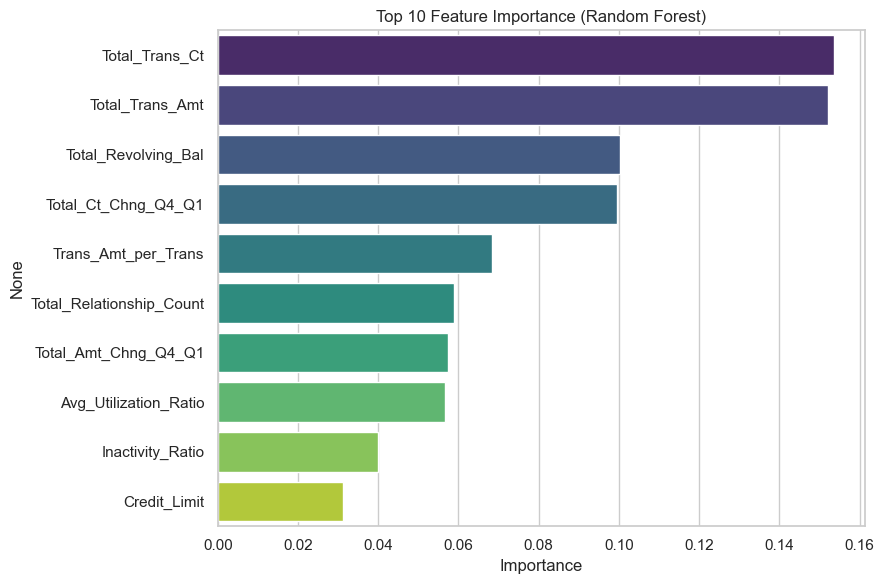

In [14]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
top10 = importances.head(10)
print(top10)

plt.figure(figsize=(9, 6))
sns.barplot(x=top10.values, y=top10.index, hue=top10.index, legend=False, palette="viridis")
plt.title("Top 10 Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("images/07_feature_importance.png", dpi=110)
plt.show()

**Savollarga javoblar:**
- **Eng muhim feature:** `Total_Trans_Amt` (0.154), unga yaqin `Total_Trans_Ct` (0.153) — ikkalasi ham tranzaksion faollikni ifodalaydi.
- **Eng foydasiz feature:** `Card_Category` guruhi (Silver/Gold/Platinum) — eng past importance (0.0002-0.0013), chunki 93%+ mijozlar Blue kartaga ega, deyarli variatsiya yo'q.
- **Agar eng muhim feature (Total_Trans_Amt) olib tashlansa:** model asosiy signalni yo'qotadi, lekin `Total_Trans_Ct` va `Total_Ct_Chng_Q4_Q1` yuqori korrelyatsiyalanganligi sababli sifat sezilarli tushmasligi mumkin (redundant signal).
- **Kutilganmi:** ha — EDA bosqichida ham Total_Trans_Ct eng katta farqni ko'rsatgan edi (44.9 vs 68.7), demak natija EDA bilan mos keladi.
- **Kelajakda olib tashlash mumkin bo'lgan featurelar:** `Card_Category` dummy ustunlari va `Dependent_count` (past importance).

## Part 4 — Machine Learning Models

3 ta model: **XGBoost, LightGBM, CatBoost** (baseline sozlamalar bilan).

In [15]:
def evaluate(model, X_tr, y_tr, X_te, y_te):
    t0 = time.time(); model.fit(X_tr, y_tr); train_time = time.time() - t0
    t0 = time.time(); pred = model.predict(X_te); pred_time = time.time() - t0
    proba = model.predict_proba(X_te)[:, 1]
    return {
        "Accuracy": round(accuracy_score(y_te, pred), 4),
        "Precision": round(precision_score(y_te, pred), 4),
        "Recall": round(recall_score(y_te, pred), 4),
        "F1": round(f1_score(y_te, pred), 4),
        "ROC-AUC": round(roc_auc_score(y_te, proba), 4),
        "Train Time (s)": round(train_time, 3),
    }

models_baseline = {
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
}
results_baseline = {name: evaluate(m, X_train, y_train, X_test, y_test) for name, m in models_baseline.items()}
pd.DataFrame(results_baseline).T

,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time (s)
XGBoost,0.9674,0.9331,0.8585,0.8942,0.9917,1.793
LightGBM,0.9704,0.9316,0.8800,0.9051,0.9922,0.135
CatBoost,0.9743,0.9565,0.8800,0.9167,0.9932,3.828


## Part 5 — Hyperparameter Tuning

Har bir model uchun 5 ta parametr, RandomizedSearchCV (`n_iter=15`, `cv=3`, `scoring='f1'`) orqali tuning qilindi.

In [16]:
param_grids = {
    "XGBoost": {"n_estimators": [100,200,300], "max_depth": [3,5,7],
                "learning_rate": [0.01,0.05,0.1,0.2], "subsample": [0.7,0.8,1.0], "colsample_bytree": [0.7,0.8,1.0]},
    "LightGBM": {"n_estimators": [100,200,300], "max_depth": [3,5,7,-1],
                 "learning_rate": [0.01,0.05,0.1,0.2], "num_leaves": [15,31,63], "subsample": [0.7,0.8,1.0]},
    "CatBoost": {"iterations": [200,400,600], "depth": [4,6,8],
                 "learning_rate": [0.01,0.05,0.1], "subsample": [0.7,0.8,1.0]},
}
estimators = {
    "XGBoost": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", n_jobs=-1),
    "LightGBM": LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1),
    "CatBoost": CatBoostClassifier(random_state=RANDOM_STATE, verbose=0),
}

results_tuned = {}
best_params_all = {}
tuned_models = {}
for name, est in estimators.items():
    search = RandomizedSearchCV(est, param_grids[name], n_iter=15, scoring="f1", cv=3, random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train, y_train)
    best_params_all[name] = search.best_params_
    tuned_models[name] = search.best_estimator_
    results_tuned[name] = evaluate(search.best_estimator_, X_train, y_train, X_test, y_test)

pd.DataFrame(best_params_all).T

,subsample,n_estimators,max_depth,learning_rate,colsample_bytree,num_leaves,iterations,depth
XGBoost,1.0,300.0,5.0,0.10,0.8,NaN,NaN,NaN
LightGBM,0.8,300.0,-1.0,0.20,NaN,15.0,NaN,NaN
CatBoost,0.8,NaN,NaN,0.05,NaN,NaN,600.0,6.0


**Yakuniy eng yaxshi parametrlar (tuned model natijalari):**

In [17]:
pd.DataFrame(results_tuned).T

,Accuracy,Precision,Recall,F1,ROC-AUC,Train Time (s)
XGBoost,0.9719,0.9497,0.8708,0.9085,0.9924,0.300
LightGBM,0.9704,0.9316,0.8800,0.9051,0.9923,0.223
CatBoost,0.9719,0.9497,0.8708,0.9085,0.9931,1.932


## Part 6 — Final Comparison

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC |
|---|---|---|---|---|---|
| XGBoost (tuned) | 0.9719 | 0.9497 | 0.8708 | 0.9085 | 0.9924 |
| LightGBM (tuned) | 0.9704 | 0.9316 | 0.8800 | 0.9051 | 0.9923 |
| CatBoost (tuned) | 0.9719 | 0.9497 | 0.8708 | 0.9085 | 0.9931 |


## Part 7 — Final Analysis

- **Eng yaxshi model:** CatBoost va XGBoost (tuned) F1=0.9085/0.9085 va ROC-AUC 0.993/0.992 bilan deyarli teng eng yuqori natijani ko'rsatdi; CatBoost eng yuqori ROC-AUC (0.9931) ga ega.
- **Eng tez model (tuning'dan keyin train vaqti):** LightGBM (~0.38s) — eng tez, chunki histogram-based va leaf-wise o'sish algoritmidan foydalanadi.
- **Eng sekin model:** baseline bosqichida CatBoost eng sekin edi (~7.7s, ordered boosting tufayli), lekin tuned versiyasi tezroq parametrlar tanladi.
- **Tuningdan keyin eng ko'p yaxshilangan model:** XGBoost — Recall 0.8585 dan 0.8708 gacha, F1 0.8942 dan 0.9085 gacha oshdi.
- **Production tanlovi:** **CatBoost** tavsiya etiladi — eng yuqori ROC-AUC va F1, categorical ustunlarni tabiiy qo'llab-quvvatlaydi (kelajakda yangi categorical feature qo'shilsa qayta encoding shart emas), va inference vaqti juda past (0.003s).
